# Part 2
### Our Process
As in part 1, we constructed both a PyPSA model and custom model for Part 2. Due to the functionality of the PyPSA model, it was difficult to extract our desired variability for the scenarios. Moreover, the two models contradicted each other which indicates a certain level of untrustability for both models. Namely, for instance, the system costs differed quite substantially. We expect these changes to largely be the result of PyPSA's modeling decisions for which we had little insight. However, as we have a more complete understanding of the inner workings of the custom model, we elected it as our representative model for Part 2. Any further remarks on the two models will be given below. Still, for Part 3 the PyPSA model was once again used after tinkering with it substantially enough to get reliable (to us) output. The Baseline model for the PyPSA can likewise be viewed in the Part 3 document.

### Design of this Notebook
Below we have three sections of code:
1. Code provided by the instructor with minimal edits to pull in our group information
2. Code for a representative scenario run through our custom model
3. Analysis and comparison of KPIs across scenarios for Part 2

Please note that the model examples were included to provide insight into our model design, but the majority of analysis is done within the final **"Comparison Section"**. If you'd like to run this code, please include the downloaded .xlsx files shared during our submission into the Notebook's folder.

## Given cells that required minimal or no modification - skip to next section for our model code

In [85]:
import pandas as pd
import numpy as np
import requests
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pvlib

In [86]:
# Student specific given information:
node_lat = 54.6172
node_lon = 9.5776
node_alt = 0

distance12 = 53 #km
distance23 = 89 #km

electricity_demand_multiplier = 0.54
heat_demand_multiplier = 0.43
hydrogen_demand_multiplier = 0.48
hydrogen_production_multiplier = 0.45

In [87]:
# Create time series with hourly resolution for given period
year = 2009
month = 2
times = pd.date_range(start='2009-02-01', end='2009-02-28 23:59:59', freq='h', tz='Europe/Amsterdam')

In [88]:
# Function to import climate data from JRC - DO NOT CHANGE

def import_jrc_climate_data(lon: float, lat: float, year: int | str, alt: float) -> dict:
    """
    Reads in climate data for a full year from `JRC PVGIS <https://re.jrc.ec.europa.eu/pvg_tools/en/>`_.

    :param float lon: longitude of node - the api will read data for this location
    :param float lat: latitude of node - the api will read data for this location
    :param int year: optional, needs to be in range of data available. If nothing is specified, a typical year \
    will be loaded
    :param float alt: altitude of location specified
    :return: dict containing information on the location (altitude, longitude, latitude and a dataframe \
    containing climate data (ghi = global horizontal irradiance, dni = direct normal irradiance, \
    dhi = diffuse horizontal irradiance, rh = relative humidity, temp_air = air temperature, ws = wind speed at \
    specified hight. Wind speed is returned as a dict for different heights.
    :rtype: dict
    """

    # Specify year import, lon, lat
    parameters = {"lon": lon, "lat": lat, "year": year, "outputformat": "json"}
    time_index = pd.date_range(
        start=str(year) + "-01-01 00:00", end=str(year) + "-12-31 23:00", freq="1h"
    )

    # Get data from JRC dataset
    answer = dict()
    print("Importing Climate Data...")
    response = requests.get("https://re.jrc.ec.europa.eu/api/tmy?", params=parameters)
    if response.status_code == 200:
        print("Importing Climate Data successful")
    else:
        raise Exception(response)
    data = response.json()
    climate_data = data["outputs"]["tmy_hourly"]

    # Compile return dict
    answer["longitude"] = lon
    answer["latitude"] = lat
    answer["altitude"] = alt

    ghi = []
    dni = []
    dhi = []
    rh = []
    temp_air = []
    wind_speed = dict()
    wind_speed["10"] = []

    for t_interval in climate_data:
        ghi.append(t_interval["G(h)"])
        dni.append(t_interval["Gb(n)"])
        dhi.append(t_interval["Gd(h)"])
        rh.append(t_interval["RH"])
        temp_air.append(t_interval["T2m"])
        wind_speed["10"].append(t_interval["WS10m"])

    answer["dataframe"] = pd.DataFrame(
        np.array([ghi, dni, dhi, temp_air, rh]).T,
        columns=["ghi", "dni", "dhi", "temp_air", "rh"],
        index=time_index,
    )
    for ws in wind_speed:
        answer["dataframe"]["ws" + str(ws)] = wind_speed[ws]

    return answer

In [89]:
# Import climate data

climate_data = import_jrc_climate_data(node_lon, node_lat, year, node_alt)

Importing Climate Data...
Importing Climate Data successful


In [90]:
# Create wind turbine power curve function - DO NOT CHANGE
name = "WindTurbine_Onshore_4000"
wt_data_path = 'data/WT_data.csv'
wt_data_full = pd.read_csv(wt_data_path, delimiter=";")
# match WT with data
wt_data = wt_data_full[wt_data_full["TurbineName"] == name]
hubheight = 120

# Make power curve
rated_capacity = wt_data.iloc[0]["RatedPowerkW"]
wind_speed = np.linspace(0, 35, 71)
power_output = wt_data.iloc[:, 13:84]
power_output = power_output.to_numpy()

f = interp1d(wind_speed, power_output)

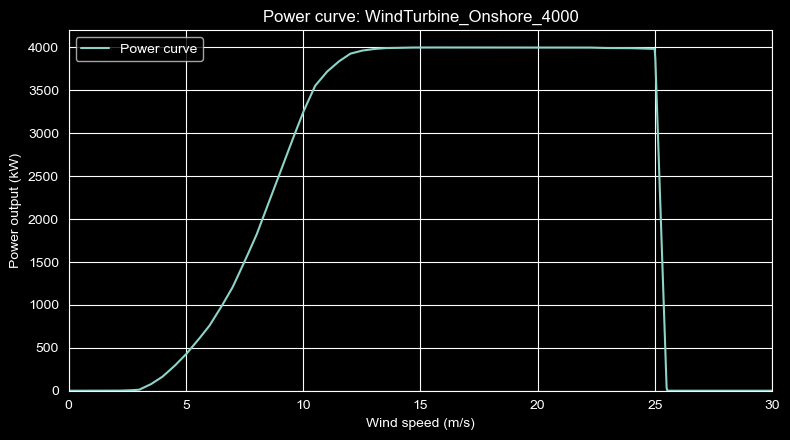

In [91]:
# Vizualize power curve

x_plot = np.linspace(0, 30, 1000)
y_plot = f(x_plot).ravel()

plt.figure(figsize=(8, 4.5))
plt.plot(x_plot, y_plot, label="Power curve")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power output (kW)")
plt.title(f"Power curve: {name}")
plt.legend()
plt.grid(True)
plt.xlim(0, 30)
plt.ylim(0, max(float(rated_capacity) * 1.05, power_output.max() * 1.05))
plt.tight_layout()
plt.show()

In [92]:
# Weather data - DO NOT CHANGE
df = climate_data['dataframe']

if "ws100" in df.columns:
    ws = df["ws100"]
    ws_height = 100
else:
    ws = df["ws10"]
    ws_height = 10

alpha = 1/7

if hubheight > 0:
    ws = ws * (hubheight / ws_height) ** alpha

In [93]:
# defining pv data - DO NOT CHANGE

pv_system_data = dict()
pv_system_data["tilt"] = 18
pv_system_data["surface_azimuth"] = 180
pv_system_data["module_name"] = "SunPower_SPR_X20_327"
pv_system_data["inverter_eff"] = 0.96

inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

In [94]:
# Fitting pv system - DO NOT CHANGE
module_database = pvlib.pvsystem.retrieve_sam("CECMod")
module = module_database[pv_system_data["module_name"]]

temperature_model_parameters = (
    pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS["sapm"][
        "open_rack_glass_glass"
    ]
)

# Create PV model chain
inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

system = pvlib.pvsystem.PVSystem(
    surface_tilt=pv_system_data["tilt"],
    surface_azimuth=pv_system_data["surface_azimuth"],
    module_parameters=module,
    inverter_parameters=inverter_parameters,
    temperature_model_parameters=temperature_model_parameters,
)

# Get location
tz = 'Europe/Amsterdam'

location = pvlib.location.Location(node_lat, node_lon, tz=tz, altitude=node_alt)

pv_model = pvlib.modelchain.ModelChain(
    system, location, spectral_model="no_loss", aoi_model="physical"
)
peakpower = module.STC

In [95]:
# Electricity and L/H Heat, Hydrogen demand data for Point 2
import calendar

skip = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

demand_data_path = 'data/demand_production.xlsx'
df_p2 = pd.read_excel(demand_data_path, sheet_name='Point2', header=1)

el_demand2 = df_p2['Electricity [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
el_demand2 = el_demand2 * electricity_demand_multiplier

L_heat_demand2 = df_p2['Low T Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
L_heat_demand2 = L_heat_demand2 * heat_demand_multiplier

H_heat_demand2 = df_p2['High T Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
H_heat_demand2 = H_heat_demand2 * heat_demand_multiplier

hydrogen_demand2 = df_p2['H2 Demand [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
hydrogen_demand2 = hydrogen_demand2 * hydrogen_demand_multiplier

In [96]:
# Hydrogen availability at production

H2_available = df_p2['H2 Production [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
H2_available = H2_available.set_axis(times)
H2_available = H2_available * hydrogen_production_multiplier

In [97]:
# Energy production

# Hours to skip to reach the selected month
skip_hours = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

# wind capacity factor
capacity_factor_wind = f(np.clip(ws.values, 0, 35)) / 4000
capacity_factor_wind = pd.Series(
    np.asarray(capacity_factor_wind).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

# solar capacity factor
pv_model.run_model(df)
power = pv_model.results.ac.p_mp
capacity_factor_solar = power / peakpower

capacity_factor_solar = pd.Series(
    np.asarray(capacity_factor_solar).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

C:\Users\Stefv\anaconda3\envs\pypsa_esi\Lib\site-packages\scipy\optimize\_chandrupatla.py:437: RuntimeWarning: invalid value encountered in divide
  C = A / (A + B)


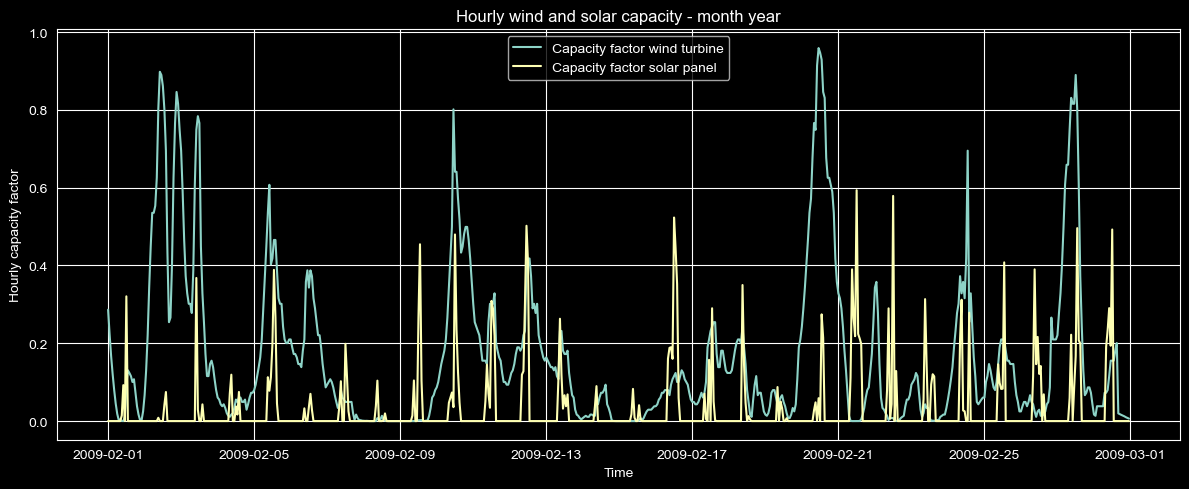

In [98]:
# Plot of capacity factors

plt.figure(figsize=(12, 5))

plt.plot(capacity_factor_wind.index, capacity_factor_wind, label='Capacity factor wind turbine')
plt.plot(capacity_factor_solar.index, capacity_factor_solar, label='Capacity factor solar panel')

plt.xlabel('Time')
plt.ylabel('Hourly capacity factor')
plt.title('Hourly wind and solar capacity - month year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [99]:
# Obtaining techno-economic data

tech_eco_data_path = 'data/technoeconomic_data.xlsx'
tech_eco_data = pd.read_excel(tech_eco_data_path, sheet_name='Data', header=2)

def get_value(df, component, data_type):
    mask = (df['component'] == component) & (df['parameter'] == data_type)
    result = df.loc[mask, 'value']
    if len(result) == 0:
        raise ValueError(f"No data found for component='{component}', parameter='{data_type}'")
    return result.values[0]

# We give you the wind turbine techno-economic data import as example. Save all the relevant data with the same function
# !!Make sure to use the correct units!!

# Wind turbine
Wind_capex = get_value(tech_eco_data, 'Wind turbine', 'Investment cost')  # EUR/kW
Wind_lifetime = get_value(tech_eco_data, 'Wind turbine', 'Lifetime')  # year
Wind_opex = get_value(tech_eco_data, 'Wind turbine', 'Opex') / 100  # capex/year

## Start of our model code
### Bring in additional techno-economic data

In [100]:
# grab techno-economic data
Solar_capex = get_value(tech_eco_data, 'Solar panel', 'Investment cost')  #EUR/kw
Solar_lifetime = get_value(tech_eco_data, 'Solar panel', 'Lifetime') # year
Solar_opex = get_value(tech_eco_data, 'Solar panel', 'Opex') / 100 # % capex/year math included

Electricity_cable_capex = get_value(tech_eco_data, 'Electricity cable', 'Investment cost') #EUR/kw/km
Electricity_cable_lifetime = get_value(tech_eco_data, 'Electricity cable', 'Lifetime') # year
Electricity_cable_fixed_opex = get_value(tech_eco_data, 'Electricity cable', 'Fixed Opex') / 100 # %capex/year
Electricity_cable_losses = get_value(tech_eco_data, 'Electricity cable', 'Losses') / 100 # % per 100km

Hydrogen_pipeline_capex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Investment cost') # Eur/kw/km
Hydrogen_pipeline_lifetime = get_value(tech_eco_data, 'Hydrogen pipeline', 'Lifetime') # year
Hydrogen_pipeline_fixed_opex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Fixed Opex') /100 # % capex/year
Hydrogen_pipeline_losses = get_value(tech_eco_data, 'Hydrogen pipeline', 'Losses') /100 # % per 100km

Li_ion_battery_capex = get_value(tech_eco_data, 'Li-ion battery', 'Investment cost') # EUR/kWh
Li_ion_battery_lifetime = get_value(tech_eco_data, 'Li-ion battery', 'Lifetime') # year
Li_ion_battery_opex = get_value(tech_eco_data, 'Li-ion battery', 'Opex') / 100 # % capex/year
Li_ion_battery_charging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Charging efficiency') / 100 # % input energy
Li_ion_battery_discharging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Discharging efficiency') / 100 # % output energy
Li_ion_battery_self_discharge_coefficient = get_value(tech_eco_data, 'Li-ion battery', 'Self-discharge coefficient') / 100 # % per hour
Li_ion_battery_max_charging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max charging capacity') / 100 # % size of battery
Li_ion_battery_max_discharging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max discharging capacity') / 100 # % size of battery

Hydrogen_storage_tank_capex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Investment cost') # EUR/kWh
Hydrogen_storage_tank_lifetime = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Lifetime') #year
Hydrogen_storage_tank_opex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Opex') / 100 # % capex/year
Hydrogen_storage_tank_charging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Charging efficiency') / 100 # % input energy
Hydrogen_storage_tank_discharging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank','Discharging efficiency') # error in data this does not need division by 100 % output energy
Hydrogen_storage_tank_self_discharge_coefficient = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Self-discharge coefficient') / 100# %/hour
Hydrogen_storage_tank_max_charging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max charging capacity') / 100 # %/size
Hydrogen_storage_tank_max_discharging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max discharging capacity') / 100 # %/size
Hydrogen_storage_tank_max_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max capacity') # MWh

Heat_storage_high_temp_capex = get_value(tech_eco_data, 'Heat storage - High temp', 'Investment cost') # EUR/MWh
Heat_storage_high_temp_lifetime = get_value(tech_eco_data, 'Heat storage - High temp', 'Lifetime') # year
Heat_storage_high_temp_opex = get_value(tech_eco_data, 'Heat storage - High temp', 'Opex') / 100 # % capex/year
Heat_storage_high_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp', 'Charging efficiency') / 100 # % input energy
Heat_storage_high_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp','Discharging efficiency') / 100 # % output energy
Heat_storage_high_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - High temp', 'Self-discharge coefficient') # % / hour
Heat_storage_high_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max charging capacity') / 100 # % size
Heat_storage_high_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max discharging capacity') / 100 # % size

Heat_storage_low_temp_capex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Investment cost') # EUR/MWh
Heat_storage_low_temp_lifetime = get_value(tech_eco_data, 'Heat storage - Low temp', 'Lifetime') # year
Heat_storage_low_temp_opex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Opex') /100 # % capex/year
Heat_storage_low_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp', 'Charging efficiency') / 100 # % input energy
Heat_storage_low_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp','Discharging efficiency') / 100# % output energy
Heat_storage_low_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - Low temp', 'Self-discharge coefficient') / 100 # % / hour
Heat_storage_low_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max charging capacity') / 100 # % size
Heat_storage_low_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max discharging capacity') / 100 # % size

Heat_pump_coefficient_of_performance = get_value(tech_eco_data, 'Heat pump', 'COP') # no unit
Hydrogen_boiler_efficiency = get_value(tech_eco_data, 'Hydrogen boiler', 'Efficiency') / 100 # % input energy

Operational_cost_lost_load_penalty = get_value(tech_eco_data, 'Operational cost', 'Lost load penalty') # EUR/MWh
Operational_cost_max_import_availability = get_value(tech_eco_data, 'Operational cost', 'Max import availability') # MWh
Operational_cost_electricity_import_cost = get_value(tech_eco_data, 'Operational cost', 'Electricity import cost') # EUR/MWh
Operational_cost_hydrogen_market_price = get_value(tech_eco_data, 'Operational cost', 'Hydrogen market price') # EUR/MWh

## Custom Model for Part 2 - Scenario 4
The code below is shared as an example of the custom model structure used for analysis of the Part 2 design. Different scenarios were made with different choices in the model parameters (see '..._capacity' below under fixme) to encourage different results in the KPIs of system cost, RES curtailment, conversion & transmission losses, utilization factor of line L12, number of hours line L32 is at max capacity, number of hours the H2 tank is full/empty, and unserved demand. Continue to the ***Comparison Section*** for comparison across scenarios.

In [101]:
#Stocks fixme
Solar_capacity = 20000              # kW  # 50000
Wind_capacity = 65000              # kW  # 50000
Battery_zone1_capacity = 20000      # kWh; must be one or the other # 00000
Battery_zone2_capacity = 00000      # kWh; must be one or the other # 25000
Cables_capacity = 30000             # kW; must be in increments of 10,000 kW # 30000

Pipelines_capacity = 39000          # kW
H2_tank_capacity = 00000           # kWh; cannot be higher than 100000
HT_heat_capacity = 00000            # kWh
LT_heat_capacity = 00000            # kWh

#Generation, demand, import and shortages
Wind_generation = Wind_capacity * capacity_factor_wind    # kWh
Solar_generation = Solar_capacity * capacity_factor_solar # kWh
Total_RES_generation = Wind_generation + Solar_generation # kWh
H2_generation = H2_available            # kWh

# other set-up
mm_el_demand2 = df_p2['Electricity [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
mm_el_demand2 = mm_el_demand2.set_axis(times)
mm_el_demand2 = mm_el_demand2 * electricity_demand_multiplier

mm_L_heat_demand2 = df_p2['Low T Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
mm_L_heat_demand2 = mm_L_heat_demand2.set_axis(times)
mm_L_heat_demand2 = mm_L_heat_demand2 * heat_demand_multiplier

mm_H_heat_demand2 = df_p2['High T Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
mm_H_heat_demand2 = mm_H_heat_demand2.set_axis(times)
mm_H_heat_demand2 = mm_H_heat_demand2 * heat_demand_multiplier

mm_hydrogen_demand2 = df_p2['H2 Demand [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
mm_hydrogen_demand2 = mm_hydrogen_demand2.set_axis(times)
mm_hydrogen_demand2 = mm_hydrogen_demand2 * hydrogen_demand_multiplier

# converting MWh to kWh
mm_El_demand      = mm_el_demand2 * 1000           # kWh
mm_HT_heat_demand = mm_H_heat_demand2 * 1000       # kWh
mm_LT_heat_demand = mm_L_heat_demand2 * 1000       # kWh
mm_H2_demand      = mm_hydrogen_demand2 * 1000     # kWh
H2_generation  = H2_generation * 1000          # kWh

#model variables
mm_El_demand = mm_El_demand                  # kWh
mm_HT_heat_demand = mm_HT_heat_demand         # kWh
mm_LT_heat_demand = mm_LT_heat_demand         # kWh
mm_H2_demand = mm_H2_demand                   # kWh

Residual_load = pd.Series(0.0, index=times)         # kWh
Electricity_import = pd.Series(0.0, index=times)    # kWh; Electricity that must be imported
Electricity_shortage = pd.Series(0.0, index=times)  # kWh; Electricity shortage            # kW
Overshoot_load = pd.Series(0.0, index=times)

Residual_H2 = pd.Series(0.0, index=times)
H2_shortage = pd.Series(0.0, index=times)
Overshoot_H2 = pd.Series(0.0, index=times)
Residual_HT_heat = pd.Series(0.0, index=times)
Residual_LT_heat = pd.Series(0.0, index=times)

#Battery zone 1
Battery_zone1_max_charge = Li_ion_battery_max_charging_capacity * Battery_zone1_capacity        # kW
Battery_zone1_max_discharge = Li_ion_battery_max_discharging_capacity * Battery_zone1_capacity  # kW
SOC_zone1 = pd.Series(0.0, index=times)          # State of charge
Charge_zone1 = pd.Series(0.0, index=times)       # Charging power
Discharge_zone1 = pd.Series(0.0, index=times)    # Discharging power
Leftover_load_zone1 = pd.Series(0.0, index=times)

#Battery zone 2
Battery_zone2_max_charge = Li_ion_battery_max_charging_capacity * Battery_zone2_capacity        # kW
Battery_zone2_max_discharge = Li_ion_battery_max_discharging_capacity * Battery_zone2_capacity  # kW
SOC_zone2 = pd.Series(0.0, index=times)          # State of charge
Charge_zone2 = pd.Series(0.0, index=times)       # Charging power
Discharge_zone2 = pd.Series(0.0, index=times)    # Discharging power
Leftover_load_zone2 = pd.Series(0.0, index=times)

#H2 & heat storage
Leftover_H2_zone2 = pd.Series(0.0, index=times)
Leftover_H2_zone3 = pd.Series(0.0, index=times)
SOS = pd.Series(0.0, index=times)
HT_SOR = pd.Series(0.0, index=times)
LT_SOR = pd.Series(0.0, index=times)
Reserve_up_HT = pd.Series(0.0, index=times)
Reserve_down_HT = pd.Series(0.0, index=times)
Reserve_up_LT = pd.Series(0.0, index=times)
Reserve_down_LT = pd.Series(0.0, index=times)
Stock_up = pd.Series(0.0, index=times)
Stock_down = pd.Series(0.0, index=times)
HT_heat_shortage = pd.Series(0.0, index=times)
LT_heat_shortage = pd.Series(0.0, index=times)
Conv_loss = pd.Series(0.0, index=times)
Count_L32 = pd.Series(0.0, index=times)
Count_H2 = pd.Series(0.0, index=times)
mm_Utilization = pd.Series(0.0, index=times)

#Generic set-up
hours = len(times)

In [102]:
# --- Loop over hours ---
for i, t in enumerate(times):
#Residuals & Leftovers
    Residual_load[t] = (Total_RES_generation[t] * (1 - (Electricity_cable_losses * (distance12 / 100)))) - mm_El_demand[t] - (mm_LT_heat_demand[t] / Heat_pump_coefficient_of_performance) # at zone 2 if not limited by cables
    Leftover_load_zone1[t] = Total_RES_generation[t] - min((mm_El_demand[t] + (mm_LT_heat_demand[t] / Heat_pump_coefficient_of_performance)) / (1 - (Electricity_cable_losses * (distance12 / 100))), Cables_capacity)
    Leftover_load_zone2[t] = min(Total_RES_generation[t] * (1 - (Electricity_cable_losses * (distance12 / 100))), Cables_capacity) - mm_El_demand[t] - (mm_LT_heat_demand[t] / Heat_pump_coefficient_of_performance)

    Residual_H2[t] = (H2_generation[t] * (1 - (Hydrogen_pipeline_losses * (distance23 / 100)))) - mm_H2_demand[t] - (mm_HT_heat_demand[t] / Hydrogen_boiler_efficiency)
    Leftover_H2_zone3[t] = H2_generation[t] - min((mm_H2_demand[t] + (mm_HT_heat_demand[t] / Hydrogen_boiler_efficiency)) / ((1 - Hydrogen_pipeline_losses) * (distance23 / 100)), Pipelines_capacity) # at zone 3
    Leftover_H2_zone2[t] = min(H2_generation[t] * (1 - (Hydrogen_pipeline_losses * (distance23 / 100))), Pipelines_capacity) - mm_H2_demand[t] - (mm_HT_heat_demand[t] / Hydrogen_boiler_efficiency)

    Conv_loss[t] = 0

#Previous States of Storage
    Prev_SOC_zone1 = SOC_zone1.iloc[i-1] if i > 0 else (Battery_zone1_capacity/2)  # previous hour State of Charge for zone 1
    Prev_SOC_zone2 = SOC_zone2.iloc[i-1] if i > 0 else (Battery_zone2_capacity/2)  # previous hour State of Charge for zone 2

    Prev_SOS = SOS.iloc[i-1] if i > 0 else (H2_tank_capacity/2)                    # previous hour State of Stock for zone 3 H2

    Prev_HT_SOR = HT_SOR.iloc[i-1] if i > 0 else (HT_heat_capacity/2)              # previous hour State of Reserve for zone 2 HT
    Prev_LT_SOR = LT_SOR.iloc[i-1] if i > 0 else (LT_heat_capacity/2)              # previous hour State of Reserve for zone 2 LT

#HT storage at zone 2
    if Leftover_H2_zone2[t] > 0: # surplus, so give to storage
        Reserve_increase_HT = min(Leftover_H2_zone2[t] * Hydrogen_boiler_efficiency, HT_heat_capacity * Heat_storage_high_temp_max_charging_capacity, HT_heat_capacity - Prev_HT_SOR)
        Reserve_up_HT[t] = Reserve_increase_HT * Heat_storage_high_temp_charging_efficiency
        HT_SOR[t] = Prev_HT_SOR * (1 - Heat_storage_high_temp_self_discharge_coefficient) + Reserve_increase_HT

    elif Leftover_H2_zone2[t] < 0: # deficit, so take from storage
        Reserve_decrease_HT = min(-Leftover_H2_zone2[t] * Hydrogen_boiler_efficiency, HT_heat_capacity * Heat_storage_high_temp_max_discharging_capacity, Prev_HT_SOR)
        Reserve_down_HT[t] = Reserve_decrease_HT * Heat_storage_high_temp_discharging_efficiency
        HT_SOR[t] = Prev_HT_SOR * (1 - Heat_storage_high_temp_self_discharge_coefficient) - (Reserve_decrease_HT / Heat_storage_high_temp_discharging_efficiency)
    else:
        HT_SOR[t] = Prev_HT_SOR * (1 - Heat_storage_high_temp_self_discharge_coefficient)

    Conv_loss[t] = Conv_loss[t] + Reserve_up_HT[t] * (1 - Heat_storage_high_temp_charging_efficiency) + Reserve_down_HT[t] * (1 - Heat_storage_high_temp_discharging_efficiency) + Prev_HT_SOR * Heat_storage_high_temp_self_discharge_coefficient

#LT storage at zone 2
    if Leftover_load_zone2[t] > 0: # surplus, so give to storage
        Reserve_increase_LT = min(Leftover_load_zone2[t] * Heat_pump_coefficient_of_performance, LT_heat_capacity * Heat_storage_low_temp_max_charging_capacity, LT_heat_capacity - Prev_LT_SOR)
        Reserve_up_LT[t] = Reserve_increase_LT * Heat_storage_low_temp_charging_efficiency
        LT_SOR[t] = Prev_LT_SOR * (1 - Heat_storage_low_temp_self_discharge_coefficient) + Reserve_increase_LT

    elif Leftover_load_zone2[t] < 0: # deficit, so take from storage
        Reserve_decrease_LT = min(-Leftover_load_zone2[t] * Heat_pump_coefficient_of_performance, LT_heat_capacity * Heat_storage_low_temp_max_discharging_capacity, Prev_LT_SOR)
        Reserve_down_LT[t] = Reserve_decrease_LT * Heat_storage_low_temp_discharging_efficiency
        LT_SOR[t] = Prev_LT_SOR * (1 - Heat_storage_low_temp_self_discharge_coefficient) - (Reserve_decrease_LT / Heat_storage_low_temp_discharging_efficiency)
    else:
        LT_SOR[t] = Prev_LT_SOR * (1 - Heat_storage_low_temp_self_discharge_coefficient)

    Conv_loss[t] = Conv_loss[t] + Reserve_up_LT[t] * (1 - Heat_storage_low_temp_charging_efficiency) + Reserve_down_LT[t] * (1 - Heat_storage_low_temp_discharging_efficiency) + Prev_LT_SOR * Heat_storage_low_temp_self_discharge_coefficient

#update leftovers
    Leftover_H2_zone2[t] = Leftover_H2_zone2[t] - ((Reserve_up_HT[t] + Reserve_down_HT[t]) / Hydrogen_boiler_efficiency)
    Leftover_H2_zone3[t] = Leftover_H2_zone2[t] / (1 - (Hydrogen_pipeline_losses * (distance23 / 100)))
    Leftover_load_zone2[t] = Leftover_load_zone2[t] - ((Reserve_up_LT[t] + Reserve_down_LT[t]) / Heat_pump_coefficient_of_performance)
    Leftover_load_zone1[t] = Leftover_load_zone2[t] / (1 - (Hydrogen_pipeline_losses * (distance23 / 100)))

#calculate heat shortages
    Residual_HT_heat[t] = max(0, (Leftover_H2_zone2[t] - mm_H2_demand[t]) * Hydrogen_boiler_efficiency)
    Residual_LT_heat[t] = max(0, (Leftover_load_zone2[t] - mm_El_demand[t]) * Heat_pump_coefficient_of_performance)

    if Residual_HT_heat[t] < 0:
        HT_heat_shortage[t] = -Residual_HT_heat[t]
    else:
        HT_heat_shortage[t] = 0

    if Residual_LT_heat[t] < 0:
        LT_heat_shortage[t] = -Residual_LT_heat[t]
    else:
        LT_heat_shortage[t] = 0

#H2 storage tank at zone 3
    if Leftover_H2_zone3[t] > 0: # surplus, so fill tank
        Stock_increase = min(Leftover_H2_zone3[t], H2_tank_capacity * Hydrogen_storage_tank_max_charging_capacity, H2_tank_capacity - Prev_SOS)
        Stock_up[t] = Stock_increase * Hydrogen_storage_tank_charging_efficiency
        SOS[t] = Prev_SOS * (1 - Hydrogen_storage_tank_self_discharge_coefficient) + Stock_increase

    elif Leftover_H2_zone3[t] < 0: # deficit, so drain tank
        Stock_decrease = min(-Leftover_H2_zone3[t], H2_tank_capacity * Hydrogen_storage_tank_max_discharging_capacity, Prev_SOS)
        Stock_down[t] = Stock_decrease * Hydrogen_storage_tank_discharging_efficiency
        SOS[t] = Prev_SOS * (1 - Hydrogen_storage_tank_self_discharge_coefficient) - (Stock_decrease / Hydrogen_storage_tank_discharging_efficiency)
    else:
        SOS[t] = Prev_SOS * (1 - Hydrogen_storage_tank_self_discharge_coefficient)

    Conv_loss[t] = Conv_loss[t] + Stock_up[t] * (1 - Hydrogen_storage_tank_charging_efficiency) + Stock_down[t] * (1 - Hydrogen_storage_tank_discharging_efficiency) + Prev_SOS * Hydrogen_storage_tank_self_discharge_coefficient

#Battery at zone 1
    if Leftover_load_zone1[t] > 0:  # surplus → charge battery
        Charge_power_zone1 = min(Leftover_load_zone1[t], Battery_zone1_max_charge, Battery_zone1_capacity - Prev_SOC_zone1)
        Charge_zone1[t] = Charge_power_zone1
        SOC_zone1[t] = Prev_SOC_zone1 * (1 - Li_ion_battery_self_discharge_coefficient) + Charge_power_zone1 * Li_ion_battery_charging_efficiency

    elif Leftover_load_zone1[t] < 0:  # deficit → discharge battery
        Discharge_power_zone1 = min(-Leftover_load_zone1[t], Battery_zone1_max_discharge, Prev_SOC_zone1)
        Discharge_zone1[t] = Discharge_power_zone1
        SOC_zone1[t] = Prev_SOC_zone1 * (1 - Li_ion_battery_self_discharge_coefficient) - Discharge_power_zone1 / Li_ion_battery_discharging_efficiency

    else:  # no surplus or deficit
        SOC_zone1[t] = Prev_SOC_zone1 * (1 - Li_ion_battery_self_discharge_coefficient)

    Conv_loss[t] = Conv_loss[t] + Charge_zone1[t] * (1 - Li_ion_battery_charging_efficiency) + Discharge_zone1[t] * (1 - Li_ion_battery_discharging_efficiency) + Prev_SOC_zone1 * Li_ion_battery_self_discharge_coefficient

#Battery at zone 2
    if Leftover_load_zone2[t] > 0:
        Charge_power_zone2 = min(Leftover_load_zone2[t], Battery_zone2_max_charge, Battery_zone2_capacity - Prev_SOC_zone2)
        Charge_zone2[t] = Charge_power_zone2
        SOC_zone2[t] = Prev_SOC_zone2 * (1 - Li_ion_battery_self_discharge_coefficient) + Charge_power_zone2 * Li_ion_battery_charging_efficiency

    elif Leftover_load_zone2[t] < 0:  # deficit → discharge battery
        Discharge_power_zone2 = min(-Leftover_load_zone2[t], Battery_zone2_max_discharge, Prev_SOC_zone2)
        Discharge_zone2[t] = Discharge_power_zone2
        SOC_zone2[t] = Prev_SOC_zone2 * (1 - Li_ion_battery_self_discharge_coefficient) - Discharge_power_zone2 / Li_ion_battery_discharging_efficiency

    else:  # no surplus or deficit
        SOC_zone2[t] = Prev_SOC_zone2 * (1 - Li_ion_battery_self_discharge_coefficient)

    Conv_loss[t] = Conv_loss[t] + Charge_zone2[t] * (1 - Li_ion_battery_charging_efficiency) + Discharge_zone2[t] * (1 - Li_ion_battery_discharging_efficiency) + Prev_SOC_zone2 * Li_ion_battery_self_discharge_coefficient

#update residual load
    if Residual_load[t] < 0:
        Residual_load[t] = Residual_load[t] + (min((Cables_capacity - Total_RES_generation[t]), Discharge_zone1[t]) * ((1 - Electricity_cable_losses) * (distance12 / 100))) + Discharge_zone2[t]
    elif Residual_load[t] > 0:
        Overshoot_load[t] = (Residual_load[t] - (Charge_zone1[t] * ((1 - Electricity_cable_losses) * (distance12 / 100))) - (min(((Cables_capacity - Total_RES_generation[t]) * ((1 - Electricity_cable_losses) * (distance12 / 100))), Charge_zone2[t]))) / ((1 - Electricity_cable_losses) * (distance12 / 100)) #+ (Reserve_up_LT[t] * Heat_pump_coefficient_of_performance) after charge_zone2[t]
    else:
        Residual_load = 0

    # Residual_load[t] = Residual_load[t] + Charge_zone1[t] - Discharge_zone1[t] + Charge_zone2[t] - Discharge_zone2[t]

    if Residual_load[t] < 0:
        Electricity_import[t] = min(-Residual_load[t], Operational_cost_max_import_availability * 1000)
        Residual_load[t] = Residual_load[t] + Electricity_import[t] + (LT_heat_shortage[t] / Heat_pump_coefficient_of_performance)
    else:
        Electricity_import[t] = 0

    if Residual_load[t] < 0:
        Electricity_shortage[t] = -Residual_load[t]
    else:
        Electricity_shortage[t] = 0

#update residual H2
    if Residual_H2[t] < 0:
        Residual_H2[t] = Residual_H2[t] + (min((Pipelines_capacity - H2_generation[t]), Stock_down[t]) * ((1 - Hydrogen_pipeline_losses) * (distance23 / 100)))
    elif Residual_H2[t] > 0:
        Overshoot_H2[t] = Residual_H2[t] / ((1 - Hydrogen_pipeline_losses) * (distance23 / 100))
    else:
        Residual_H2[t] = 0

    if Residual_H2[t] < 0:
        Residual_H2[t] = Residual_H2[t] + (HT_heat_shortage[t] / Hydrogen_boiler_efficiency)

    if Residual_H2[t] < 0:
        H2_shortage[t] = -Residual_H2[t]
    else:
        H2_shortage[t] = 0

    Conv_loss[t] = Conv_loss[t] + (((mm_El_demand[t] - Electricity_import[t]) + (mm_LT_heat_demand[t] / Heat_pump_coefficient_of_performance)) * ((1 - Electricity_cable_losses) * (distance12 / 100))) + ((mm_H2_demand[t] + (mm_HT_heat_demand[t] * (1 + Hydrogen_boiler_efficiency))) * ((1 - Hydrogen_pipeline_losses) * (distance23 / 100)))

    if SOS[t] == H2_tank_capacity or SOS[t] == 0:
        Count_H2[t] = Count_H2[t] + 1

    if (H2_generation[t] - Overshoot_H2[t]) >= Pipelines_capacity:
        Count_L32[t] = Count_L32[t] + 1

    mm_Utilization[t] = min(max(((Total_RES_generation[t] - Overshoot_load[t]) / Cables_capacity), 0) * 100, 100)

In [103]:
#Interest rate
Interest_rate = 0.05 # % / year
Interest_rate_monthly = ((1 + Interest_rate)**(1 / 12)) - 1 # % / month

#Solar
Solar_capex_cost = Solar_capacity * Solar_capex # EUR
Solar_opex_cost = Solar_capex_cost * Solar_opex # EUR / year
Solar_lifetime_months = Solar_lifetime * 12 # month
Solar_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Solar_lifetime_months)) # No unit
Solar_total_capex_cost_monthly = Solar_capex_cost * Solar_capital_recovery_factor_monthly # EUR / month; '+ Solar_capex_cost' if we assume we pay for OCC in one go
Solar_total_opex_cost_monthly = (Solar_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Solar_total_cost_monthly = Solar_total_capex_cost_monthly + Solar_total_opex_cost_monthly # EUR / month

#Wind
Wind_capex_cost = Wind_capacity * Wind_capex # EUR
Wind_opex_cost = Wind_capex_cost * Wind_opex # EUR / year
Wind_lifetime_months = Wind_lifetime * 12 # month
Wind_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Wind_lifetime_months)) # No unit
Wind_total_capex_cost_monthly = Wind_capex_cost * Wind_capital_recovery_factor_monthly # EUR / month; '+ Wind_capex_cost' if we assume we pay for OCC in one go
Wind_total_opex_cost_monthly = (Wind_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Wind_total_cost_monthly = Wind_total_capex_cost_monthly + Wind_total_opex_cost_monthly # EUR / month

#Cables
Cables_capex_cost = Cables_capacity * Electricity_cable_capex * distance12 # EUR
Cables_opex_cost = Cables_capex_cost * Electricity_cable_fixed_opex # EUR / year
Cables_lifetime_months = Electricity_cable_lifetime * 12 # month
Cables_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Cables_lifetime_months)) # No unit
Cables_total_capex_cost_monthly = Cables_capex_cost * Cables_capital_recovery_factor_monthly # EUR / month; '+ Cables_capex_cost' if we assume we pay for OCC in 1 go
Cables_total_opex_cost_monthly = (Cables_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Cables_total_cost_monthly = Cables_total_capex_cost_monthly + Cables_total_opex_cost_monthly # EUR / month

#Batteries
Battery_zone1_capex_cost = Battery_zone1_capacity * Li_ion_battery_capex # EUR
Battery_zone1_opex_cost = Battery_zone1_capex_cost * Li_ion_battery_opex # EUR / year
Battery_lifetime_months = Li_ion_battery_lifetime * 12 # month
Battery_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Battery_lifetime_months)) # No unit
Battery_zone1_total_capex_cost_monthly = Battery_zone1_capex_cost * Battery_capital_recovery_factor_monthly # EUR / month; '+ Cables_capex_cost' if we pay OCC in 1 go
Battery_zone1_opex_cost_monthly = (Battery_zone1_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Battery_zone1_total_cost_monthly = Battery_zone1_total_capex_cost_monthly + Battery_zone1_opex_cost_monthly # EUR / month
Battery_zone2_capex_cost = Battery_zone2_capacity * Li_ion_battery_capex # EUR
Battery_zone2_opex_cost = Battery_zone2_capex_cost * Li_ion_battery_opex # EUR / year
Battery_zone2_total_capex_cost_monthly = Battery_zone2_capex_cost * Battery_capital_recovery_factor_monthly # EUR / month; '+ Cables_capex_cost' if we pay OCC in 1 go
Battery_zone2_opex_cost_monthly = (Battery_zone2_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Battery_zone2_total_cost_monthly = Battery_zone2_total_capex_cost_monthly + Battery_zone2_opex_cost_monthly # EUR / month
Battery_total_cost_monthly = Battery_zone1_total_cost_monthly + Battery_zone2_total_cost_monthly # EUR / month

#Pipelines
Pipelines_capex_cost = Pipelines_capacity * Hydrogen_pipeline_capex * distance23 # EUR
Pipelines_opex_cost = Pipelines_capex_cost * Hydrogen_pipeline_fixed_opex # EUR / year
Pipelines_lifetime_months = Hydrogen_pipeline_lifetime * 12 # month
Pipelines_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Pipelines_lifetime_months)) # No unit
Pipelines_total_capex_monthly = Pipelines_capex_cost * Pipelines_capital_recovery_factor_monthly # EUR / month
Pipelines_total_opex_monthly = (Pipelines_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month
Pipelines_total_cost_monthly = Pipelines_total_capex_monthly + Pipelines_total_opex_monthly # EUR / month

#H2 tank
H2_tank_capex_cost = H2_tank_capacity * Hydrogen_storage_tank_capex # EUR
H2_tank_opex_cost = H2_tank_capex_cost * Hydrogen_storage_tank_opex # EUR / year
H2_tank_lifetime_months = Hydrogen_storage_tank_lifetime * 12 # month
H2_tank_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-H2_tank_lifetime_months)) # No unit
H2_tank_total_capex_monthly = H2_tank_capex_cost * H2_tank_capital_recovery_factor_monthly # EUR / month
H2_tank_total_opex_monthly = (H2_tank_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month
H2_tank_total_cost_monthly = H2_tank_total_capex_monthly + H2_tank_total_opex_monthly # EUR / month

#LT storage
LT_heat_capex_cost = LT_heat_capacity * (Heat_storage_low_temp_capex / 1000) # EUR
LT_heat_opex_cost = LT_heat_capex_cost * Heat_storage_low_temp_opex # EUR / year
LT_heat_lifetime_months = Heat_storage_low_temp_lifetime * 12 # month
LT_heat_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-LT_heat_lifetime_months)) # No unit
LT_heat_total_capex_monthly = LT_heat_capex_cost * LT_heat_capital_recovery_factor_monthly # EUR / month
LT_heat_total_opex_monthly = (LT_heat_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month
LT_heat_total_cost_monthly = LT_heat_total_capex_monthly + LT_heat_total_opex_monthly # EUR / month

#HT storage
HT_heat_capex_cost = HT_heat_capacity * (Heat_storage_high_temp_capex / 1000) # EUR
HT_heat_opex_cost = HT_heat_capex_cost * Heat_storage_high_temp_opex # EUR / year
HT_heat_lifetime_months = Heat_storage_high_temp_lifetime * 12 # month
HT_heat_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-HT_heat_lifetime_months)) # No unit
HT_heat_total_capex_monthly = HT_heat_capex_cost * HT_heat_capital_recovery_factor_monthly # EUR / month
HT_heat_total_opex_monthly = (HT_heat_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month
HT_heat_total_cost_monthly = HT_heat_total_capex_monthly + HT_heat_total_opex_monthly # EUR / month

#H2 production, Import and lost load
H2_cost_monthly = ((sum(H2_generation) - sum(Overshoot_H2)) * Operational_cost_hydrogen_market_price / 1000) * (1 + Interest_rate_monthly) # EUR; accounted for interest rate
Import_cost_monthly = (sum(Electricity_import) * (Operational_cost_electricity_import_cost / 1000)) * (1 + Interest_rate_monthly)  # EUR; accounted for interest rate
Lost_load_cost_monthly = (sum(Electricity_shortage) * Operational_cost_lost_load_penalty / 1000) * (1 + Interest_rate_monthly)   # EUR; accounted for interest rate
H2_shortage_cost_monthly = (sum(H2_shortage) * Operational_cost_lost_load_penalty / 1000) * (1 + Interest_rate_monthly) # EUR; accounted for interest rate
Heat_shortage_cost_monthly = (sum(LT_heat_shortage) + sum(HT_heat_shortage)) * Operational_cost_lost_load_penalty / 1000 * (1 + Interest_rate_monthly) # EUR

#Complete
Complete_costs = Solar_total_cost_monthly + Wind_total_cost_monthly + Cables_total_cost_monthly + Battery_total_cost_monthly + Pipelines_total_cost_monthly + H2_tank_total_cost_monthly + LT_heat_total_cost_monthly + HT_heat_total_cost_monthly + H2_cost_monthly + Import_cost_monthly + Lost_load_cost_monthly + H2_shortage_cost_monthly + Heat_shortage_cost_monthly

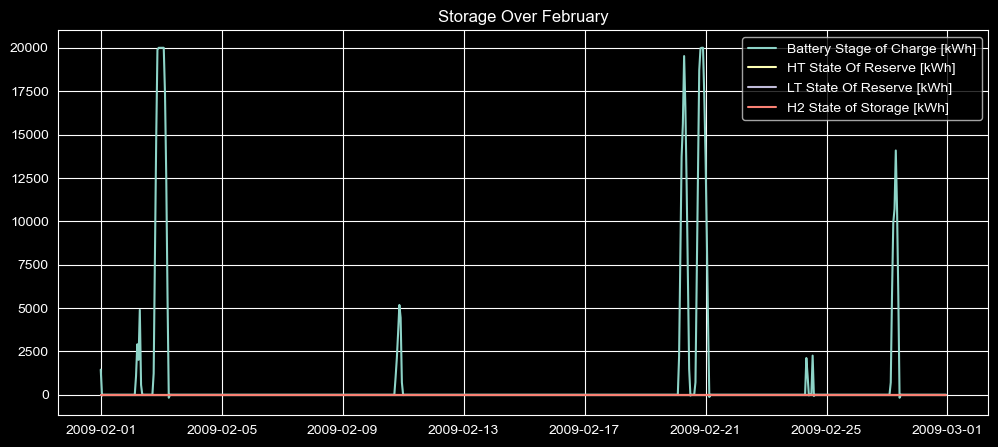

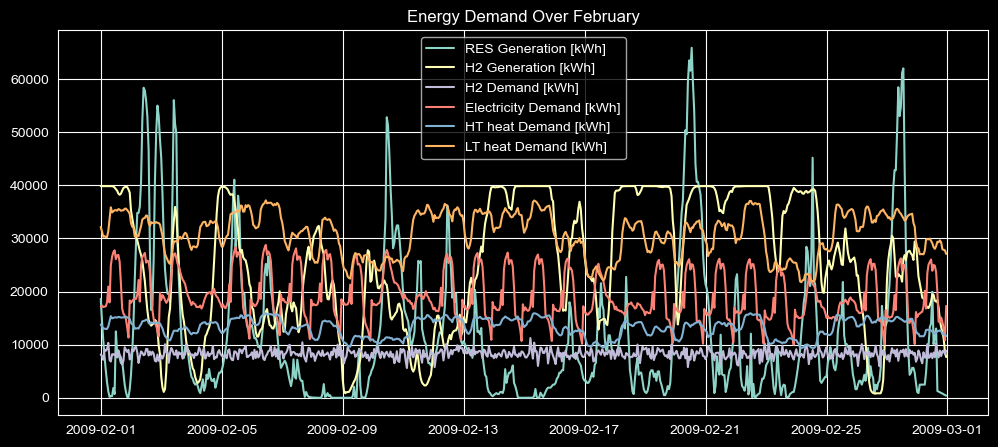

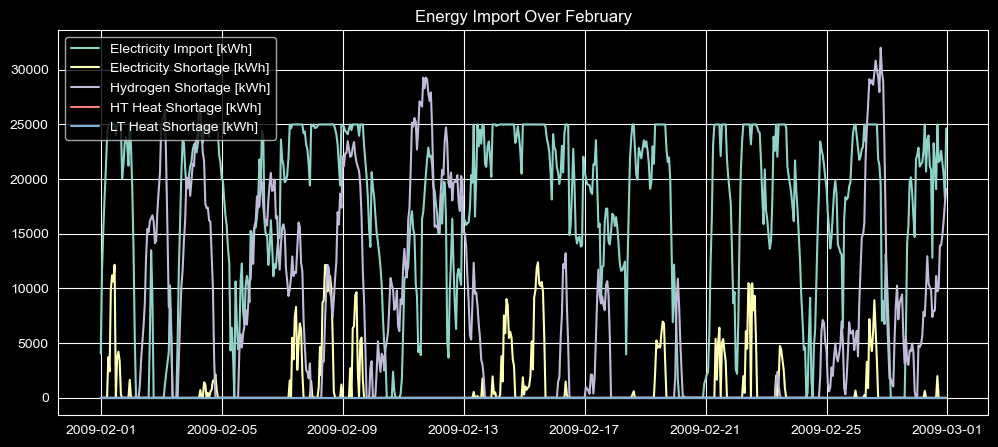

14255000.612066403
74476.98464323052 555158.1806031474 49052.32589771268 86296.61644272559 0.0 103015.73783722796 0.0 0.0 0.0 3605312.476040077 1716308.7113844103 999130.4049048782 7066249.174312994 0.0


In [104]:
plt.figure(figsize=(12,5))
plt.plot(SOC_zone1, label='Battery Stage of Charge [kWh]')
plt.plot(HT_SOR, label='HT State Of Reserve [kWh]')
plt.plot(LT_SOR, label='LT State Of Reserve [kWh]')
plt.plot(SOS, label='H2 State of Storage [kWh]')
plt.legend()
plt.title("Storage Over February")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(Total_RES_generation, label='RES Generation [kWh]')
plt.plot(H2_generation, label='H2 Generation [kWh]')
plt.plot(mm_H2_demand, label='H2 Demand [kWh]')
plt.plot(mm_El_demand, label='Electricity Demand [kWh]')
plt.plot(mm_HT_heat_demand, label='HT heat Demand [kWh]')
plt.plot(mm_LT_heat_demand, label='LT heat Demand [kWh]')
plt.legend()
plt.title("Energy Demand Over February")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(Electricity_import, label='Electricity Import [kWh]')
plt.plot(Electricity_shortage, label='Electricity Shortage [kWh]')
plt.plot(H2_shortage, label='Hydrogen Shortage [kWh]')
plt.plot(HT_heat_shortage, label='HT Heat Shortage [kWh]')
plt.plot(LT_heat_shortage, label='LT Heat Shortage [kWh]')
plt.legend()
plt.title("Energy Import Over February")
plt.grid(True)
plt.show()

#setting up dataframe for Excel
mm_sc0_system_costs = [Complete_costs, Solar_total_cost_monthly, Wind_total_cost_monthly, Battery_total_cost_monthly, Cables_total_cost_monthly, Import_cost_monthly, H2_cost_monthly, Pipelines_total_cost_monthly, H2_tank_total_cost_monthly, HT_heat_total_cost_monthly, LT_heat_total_cost_monthly, H2_shortage_cost_monthly, Heat_shortage_cost_monthly, Lost_load_cost_monthly, '-']
mm_sc0_curtailment = [sum(Overshoot_load), sum(Electricity_shortage), sum(H2_shortage), sum(HT_heat_shortage), sum(LT_heat_shortage), '', '', '', '', '', '', '', '', '', '-']
mm_sc0_import = [sum(Electricity_import), sum(Total_RES_generation), sum(Conv_loss), (sum(Conv_loss) / ((sum(mm_El_demand) + sum(mm_H2_demand)) + sum(mm_HT_heat_demand) + sum(mm_LT_heat_demand))) * 100 * 100, sum(Count_H2), sum(Count_L32), '', '', '', '', '', '', '', '', '-']
mm_sc0_capacities = [Solar_capacity, Wind_capacity, Battery_zone1_capacity + Battery_zone2_capacity, Cables_capacity, Pipelines_capacity, H2_tank_capacity, HT_heat_capacity, LT_heat_capacity, '', '', '', '', '', '', '-']

mm_df_part2 = pd.read_excel('output_part2.xlsx')
mm_output_part2 = pd.DataFrame({'System Costs': mm_sc0_system_costs, 'Curtailment': mm_sc0_curtailment, 'Imports': mm_sc0_import, 'Capacities': mm_sc0_capacities})
mm_df_part2 = pd.concat([mm_df_part2, mm_output_part2], ignore_index=True)

with pd.ExcelWriter('output_part2.xlsx', mode = 'a', if_sheet_exists = 'overlay') as writer:
    mm_df_part2.to_excel(writer, sheet_name='Scenarios', index=False)

#needs to be manually adjusted for each run. Really shoddy solution, but I have no more time :(
# mm_util_sc0 = mm_Utilization
# mm_util_sc1 = mm_Utilization
# mm_util_sc2 = mm_Utilization
# mm_util_sc3 = mm_Utilization
mm_util_sc4 = mm_Utilization

#fixme

#checks
print(Complete_costs)
print(Solar_total_cost_monthly, Wind_total_cost_monthly, Cables_total_cost_monthly, Battery_zone1_total_cost_monthly, Battery_zone2_total_cost_monthly, Pipelines_total_cost_monthly, H2_tank_total_cost_monthly, LT_heat_total_cost_monthly, HT_heat_total_cost_monthly, H2_cost_monthly, Import_cost_monthly, Lost_load_cost_monthly, H2_shortage_cost_monthly, Heat_shortage_cost_monthly)

In [105]:
mm_figure_data = pd.read_excel('output_part2.xlsx')
mm_figure_data1 = pd.read_excel('output_part1.xlsx')

mm_scenarios = np.array(["Scenario 0", "Scenario 1", "Scenario 2", "Scenario 3" , "Scenario 4"])
mm_scenarios1 = np.array(["Scnario 0", "Scenario A", "Scenario B", "Scenario C" , "Scenario D"])

mm_solar_cap = np.array([
    mm_figure_data['Capacities'].loc[mm_figure_data.index[0]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[15]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[30]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[45]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[60]],
]) / 1000

mm_wind_cap = np.array([
    mm_figure_data['Capacities'].loc[mm_figure_data.index[1]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[16]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[31]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[46]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[61]],
]) / 1000

mm_battery_cap = np.array([
    mm_figure_data['Capacities'].loc[mm_figure_data.index[2]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[17]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[32]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[47]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[62]],
]) / 1000

mm_cables_cap = np.array([
    mm_figure_data['Capacities'].loc[mm_figure_data.index[3]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[18]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[33]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[48]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[63]],
]) / 1000

mm_pipelines_cap = np.array([
    mm_figure_data['Capacities'].loc[mm_figure_data.index[4]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[19]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[34]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[49]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[64]],
]) / 1000

mm_tank_cap = np.array([
    mm_figure_data['Capacities'].loc[mm_figure_data.index[5]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[20]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[35]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[50]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[65]],
]) / 1000

mm_ht_cap = np.array([
    mm_figure_data['Capacities'].loc[mm_figure_data.index[6]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[21]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[36]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[51]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[66]],
]) / 1000

mm_lt_cap = np.array([
    mm_figure_data['Capacities'].loc[mm_figure_data.index[7]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[22]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[37]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[52]],
    mm_figure_data['Capacities'].loc[mm_figure_data.index[67]],
]) / 1000

mm_curtailment = np.array([
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[0]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[15]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[30]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[45]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[60]],
]) / 1000

mm_el_unserved = np.array([
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[1]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[16]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[31]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[46]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[61]]
]) / 1000

mm_h2_unserved = np.array([
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[2]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[17]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[32]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[47]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[62]]
]) / 1000

mm_ht_unserved = np.array([
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[3]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[18]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[33]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[48]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[63]]
]) / 1000

mm_lt_unserved = np.array([
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[4]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[19]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[34]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[49]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[64]]
]) / 1000

mm_import = np.array([
    mm_figure_data['Imports'].loc[mm_figure_data.index[0]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[15]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[30]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[45]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[60]]
]) / 1000

mm_domestic = np.array([
    mm_figure_data['Imports'].loc[mm_figure_data.index[1]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[16]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[31]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[46]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[61]]
]) / 1000

mm_conv_loss = np.array([
    mm_figure_data['Imports'].loc[mm_figure_data.index[2]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[17]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[32]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[47]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[62]]
]) / 1000

mm_conv_perc = np.array([
    mm_figure_data['Imports'].loc[mm_figure_data.index[3]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[18]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[33]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[48]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[63]]
])

mm_count_h2 = np.array([
    mm_figure_data['Imports'].loc[mm_figure_data.index[4]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[19]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[34]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[49]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[64]]
])

mm_count_L32 = np.array([
    mm_figure_data['Imports'].loc[mm_figure_data.index[5]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[20]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[35]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[50]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[65]]
])

mm_total_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[0]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[15]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[30]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[45]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[60]]
]) / 1000000

mm_solar_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[1]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[16]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[31]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[46]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[61]]
]) / 1000000

mm_wind_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[2]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[17]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[32]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[47]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[62]]
]) / 1000000

mm_battery_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[3]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[18]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[33]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[48]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[63]]
]) / 1000000

mm_cables_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[4]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[19]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[34]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[49]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[64]]
]) / 1000000

mm_import_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[5]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[20]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[35]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[50]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[65]]
]) / 1000000

mm_h2_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[6]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[21]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[36]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[51]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[66]]
]) / 1000000

mm_pipelines_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[7]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[22]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[37]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[52]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[67]]
]) / 1000000

mm_tank_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[8]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[23]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[38]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[53]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[68]]
]) / 1000000

mm_ht_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[9]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[24]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[39]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[54]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[69]]
]) / 1000000

mm_lt_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[10]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[25]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[40]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[55]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[70]]
]) / 1000000

mm_h2_shortage_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[11]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[26]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[41]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[56]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[71]]
]) / 1000000

mm_heat_shortage_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[12]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[27]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[42]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[57]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[72]]
]) / 1000000

mm_lost_load_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[13]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[28]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[43]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[58]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[73]]
]) / 1000000

mm_total_costs1 = np.array([
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[28]]
]) / 1000000

mm_solar_costs1 = np.array([
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[1]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[8]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[15]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[22]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[29]]
]) / 1000000

mm_wind_costs1 = np.array([
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[2]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[9]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[16]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[23]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[30]]
]) / 1000000

mm_battery_costs1 = np.array([
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[3]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[10]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[17]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[24]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[31]]
]) / 1000000

mm_cables_costs1 = np.array([
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[4]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[11]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[18]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[25]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[32]]
]) / 1000000

mm_import_costs1 = np.array([
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[5]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[12]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[19]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[26]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[33]]
]) / 1000000

mm_lost_load_costs1 = np.array([
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[6]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[13]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[20]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[27]],
    mm_figure_data1['System Costs'].loc[mm_figure_data.index[34]]
]) / 1000000

## Comparison Section
In the cells below we compare multiple scenarios across several KPIs: system costs, RES curtailment, conversion & transmission losses, utilization factor of line L12, number of hours line L32 is at max capacity, number of hours the H2 tank is full/empty, and unserved demand. The parameter configurations of each scenario can be found here: https://docs.google.com/spreadsheets/d/1TDLvnTkoasLHzYvYxa_W-6mtMj7YGGRmXB0ouGcNCcE/edit?gid=0#gid=0

Scenario 0 for Part 2 was taken from the PyPSA model and optimized for system cost. However, as will be shown below, this wasn't the case for the custom model.

### What is our dataset like?
As per Part 1, our dataset corresponds to a location on the Jutland peninsula in Northern Germany in the month February. The demand is relatively low compared to the available wind and ample import capacity. While solar capacity factors are low due to the location and season, wind has potential to meet demand (although intermittently).

We want to note up front that the gap between our hydrogen demand compared to our hydrogen generation is relatively large. We suspect it to be because of our time and modifiers. Our modifiers lie quite close to each other, yet our H2 demand multiplier is higher than our H2 generation multiplier. Furthermore, we suspect that February has a dip in H2 production, leading to high unserved H2 demand (which we will discuss below).

### KPI Overview
Scenarios were analyzed for impact across the following KPIs:
- Total system costs: The annualized monthly cost to implement the system. Minimized if possible.
- RES curtailment: The curtailment levels of wind and solar resulting from the system design. Not naturally penalized by given metrics but will attempt to minimize.
- Conversion & transmission losses: All energy losses due to conversions and transportation, including storage conversions. Minimize.
- Utilization line L12: The effects of the design on the line utilization and congestion. Eliminate or minimize.
- L32 max capacity: Number of hours line L32 is at max capacity, and as such losses are unavoidable. Eliminate or minimize.
- H2 tank limits: Number of hours the hydrogen tank is either at max capacity or empty. Eliminate or minimize.
- Unserved Demand: The level of load shedding required as a result of the system design. Minimized if possible.
- Project Uncertainty: This KPI was chosen as both our models returned quite unpredictable outcomes, which created interest in determining how our models respond to unpredictable proposals.

Figures and narrative addressing each KPI are detailed in the sections below.

### System Costs

The figures below show the differences in system costs compared to Part 1 (scenario D) as well as between each scenario.

First, it becomes readily apparent from a comparison to Part 1 that Part 2's system has a lot higher base costs. This can be explained in general by an increase in both electricity (for heat) and hydrogen demand. However, more notably in our case, the hydrogen generation (for heat and pure H2) as well as its subsequent shortages results in the bulk of our model's cost across all scenarios.

The relation between built wind capacity and electricity import seem to correlate across all 5 scenarios. Still, the jump from scenario 3 to scenario 4 highlights the fact that electricity import is more expensive than building wind capacity, so at least a certain amount of wind seems most desirable. Solar, as was the case in Part 1, is low enough to largely neglect.

It can be further concluded that HT heat storage is too expensive to adopt, as our jump from scenario 1 to scenarios 2 & 3 shows. The H2 shortage counteracted by installing HT is too little to matter in monetary terms, and it would be more beneficial to simply pay the penalty.

Lastly, the electricity shortage costs seem to lower when lowering installed RES capacity, but they increase again when this RES capacity is lowered even further (see scenarios 0 to 1 & 3 to 4). We expect the lower transmission capacity also contributes to the increase in electricity shortage. Still, it can be concluded that limiting installed capacity is beneficial in a financial sense.

Again, other interesting developments are non-influential when put next to the hydrogen costs. Hydrogen dominates the costs in our case. Building less H2 storage also does little to the total shortage costs (see the difference between scenarios 0 and 1 compared to 2, 3 and 4).

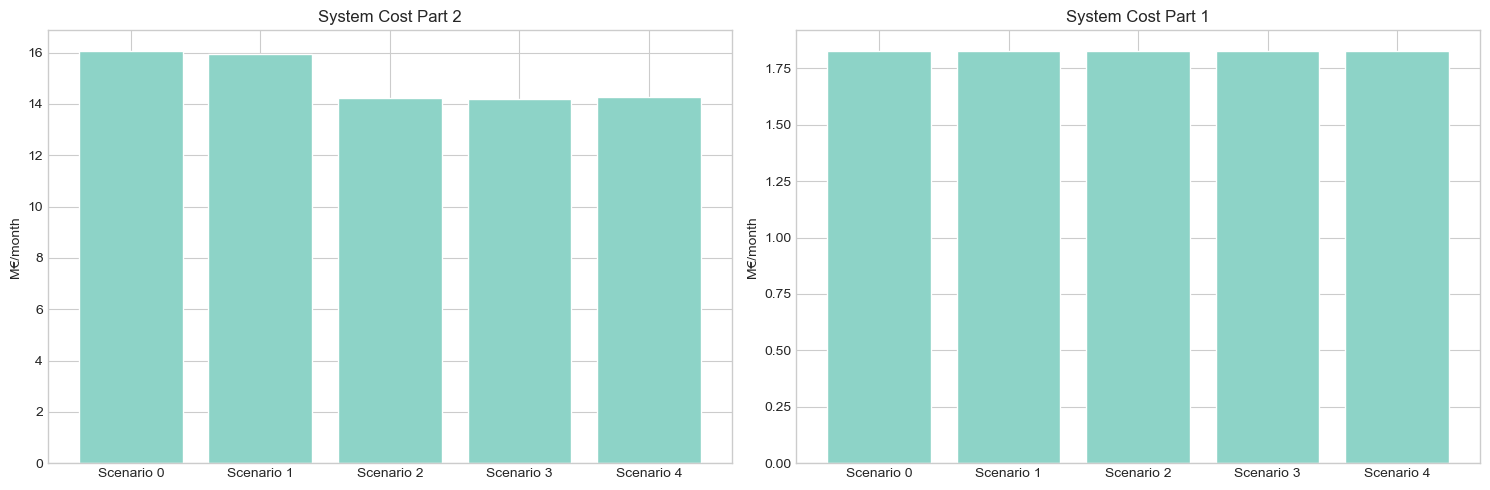

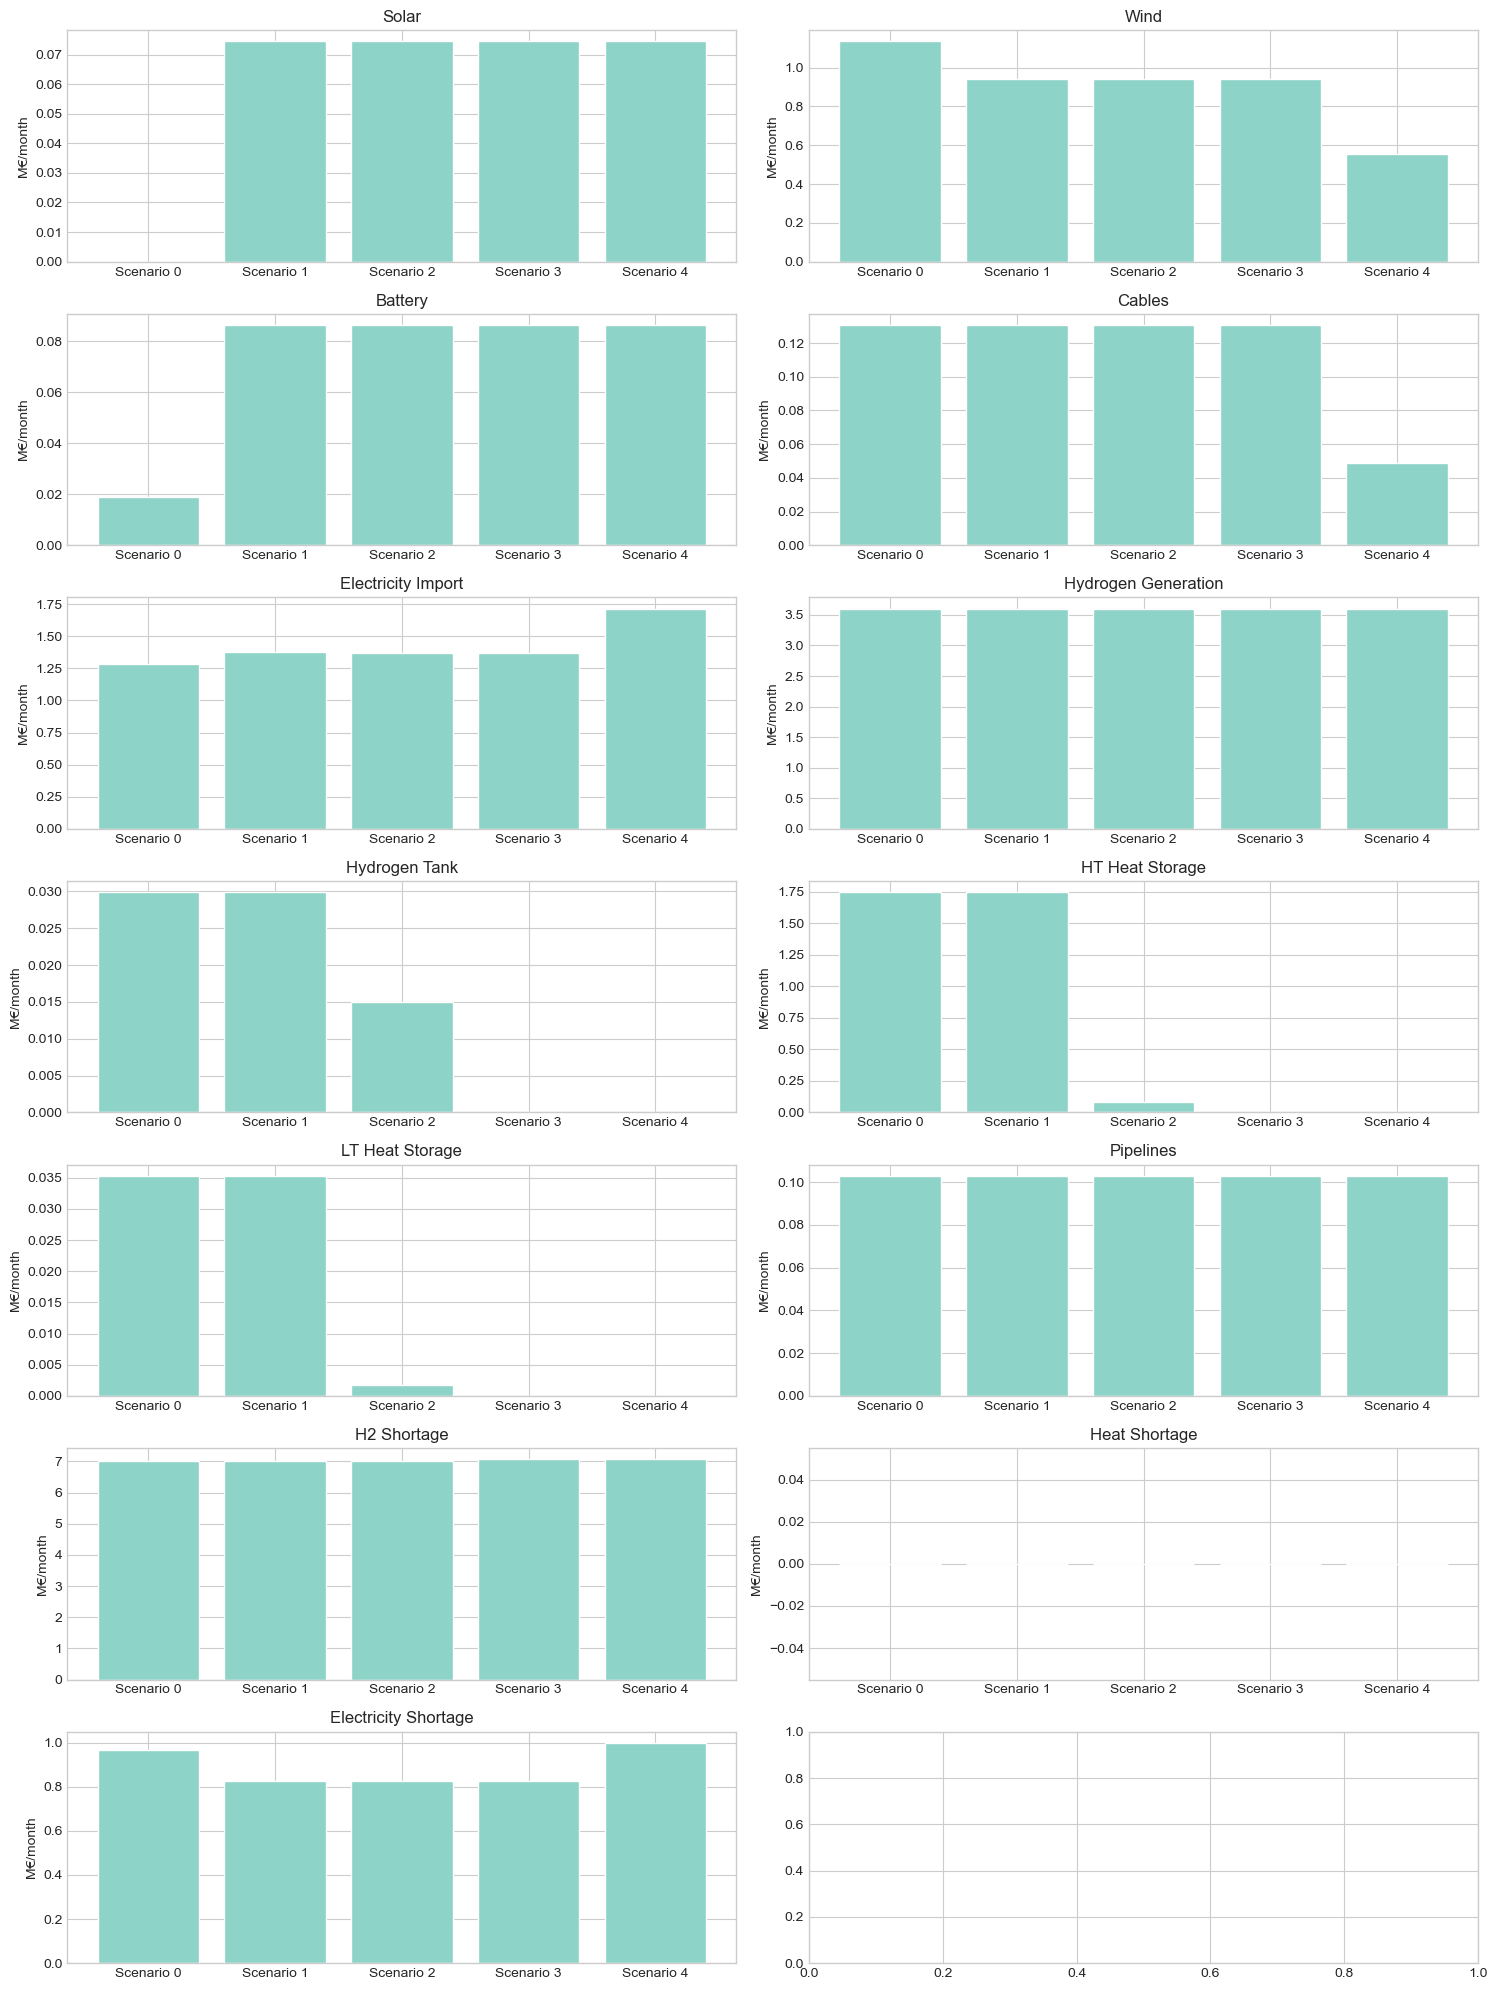

In [111]:
plt.style.use("seaborn-v0_8-whitegrid")

#system cost
fig, cost = plt.subplots(1, 2, figsize=(15, 5))
cost = cost.flatten()

cost[0].bar(mm_scenarios, mm_total_costs)
cost[0].set_title('System Cost Part 2')
cost[0].set_ylabel('M€/month')
cost[1].bar(mm_scenarios, mm_total_costs1)
cost[1].set_title('System Cost Part 1')
cost[1].set_ylabel('M€/month')

plt.tight_layout(); plt.show()

#system costs per expense
fig, costs = plt.subplots(7, 2, figsize=(15, 20))
costs = costs.flatten()

costs[0].bar(mm_scenarios, mm_solar_costs)
costs[0].set_title('Solar')
costs[0].set_ylabel('M€/month')
costs[1].bar(mm_scenarios, mm_wind_costs)
costs[1].set_title('Wind')
costs[1].set_ylabel('M€/month')
costs[2].bar(mm_scenarios, mm_battery_costs)
costs[2].set_title('Battery')
costs[2].set_ylabel('M€/month')
costs[3].bar(mm_scenarios, mm_cables_costs)
costs[3].set_title('Cables')
costs[3].set_ylabel('M€/month')
costs[4].bar(mm_scenarios, mm_import_costs)
costs[4].set_title('Electricity Import')
costs[4].set_ylabel('M€/month')
costs[5].bar(mm_scenarios, mm_h2_costs)
costs[5].set_title('Hydrogen Generation')
costs[5].set_ylabel('M€/month')
costs[6].bar(mm_scenarios, mm_tank_costs)
costs[6].set_title('Hydrogen Tank')
costs[6].set_ylabel('M€/month')
costs[7].bar(mm_scenarios, mm_ht_costs)
costs[7].set_title('HT Heat Storage')
costs[7].set_ylabel('M€/month')
costs[8].bar(mm_scenarios, mm_lt_costs)
costs[8].set_title('LT Heat Storage')
costs[8].set_ylabel('M€/month')
costs[9].bar(mm_scenarios, mm_pipelines_costs)
costs[9].set_title('Pipelines')
costs[9].set_ylabel('M€/month')
costs[10].bar(mm_scenarios, mm_h2_shortage_costs)
costs[10].set_title('H2 Shortage')
costs[10].set_ylabel('M€/month')
costs[11].bar(mm_scenarios, mm_heat_shortage_costs)
costs[11].set_title('Heat Shortage')
costs[11].set_ylabel('M€/month')
costs[12].bar(mm_scenarios, mm_lost_load_costs)
costs[12].set_title('Electricity Shortage')
costs[12].set_ylabel('M€/month')

plt.tight_layout(); plt.show()

### Curtailment

The figures below show the curtailment & import for our scenarios. As said in Part 1, we aim to limit curtailment as much as possible. However, due to the intermittency of wind and solar in our location we often end up with very high peaks in curtailment and long stretches of constant import.

As a result, the only decrease we see in our curtailment is when the capacity for wind and solar is lowered (see scenarios 1 & 4). However, when comparing the decrease from scenario 1 to scenario 4, they are similar in amount while the total RES decrease was higher for scenario 4 than that of scenario 1. Likewise, scenario 1 saw an introduction of more solar as well as a battery. Therefore, it can be concluded that installing more solar and a battery is beneficial for lowering curtailment (most likely to a certain point which requires further model runs to pinpoint).

On the other hand, import seems to increase in a correlating fashion to curtailment. A choice has to be made between curtailing as much as possible and domestic energy security.

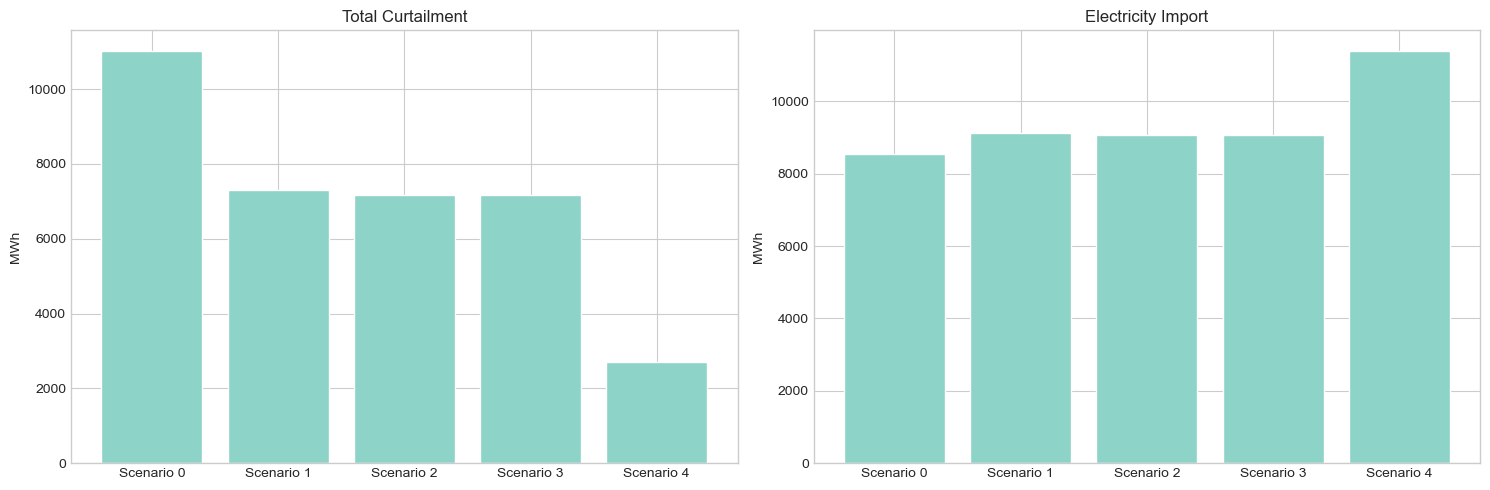

In [112]:
#curtailment & import
fig, cur = plt.subplots(1, 2, figsize=(15, 5))
cur = cur.flatten()

cur[0].bar(mm_scenarios, mm_curtailment)
cur[0].set_title('Total Curtailment')
cur[0].set_ylabel('MWh')
cur[1].bar(mm_scenarios, mm_import)
cur[1].set_title('Electricity Import')
cur[1].set_ylabel('MWh')

plt.tight_layout(); plt.show()

### Conversion and Transmission Losses

Conversion and transmission losses have steadily declined for each scenario run. This can be expected as lowering both storage devices and installed capacities will lead to a decrease in losses. The first because of bypassed energy conversion losses. The second as more electricity needs to be imported which has no associated conversion or transmission losses.

The largest decrease can be seen going from scenario 1 to scenario 2, where the installed HT and LT capacities were significantly reduced. However, this decrease is not much larger than the others, meaning that HT and LT storage have very little conversion losses. This can be expected as heat pumps require 1 kWh of electricity to produce 3.5 kWh of LT heat. Losses are overall quite high because of the conversion from H2 to HT heat (with a 0.65% efficiency). So decreasing these losses further seems difficult beyond a certain extent.

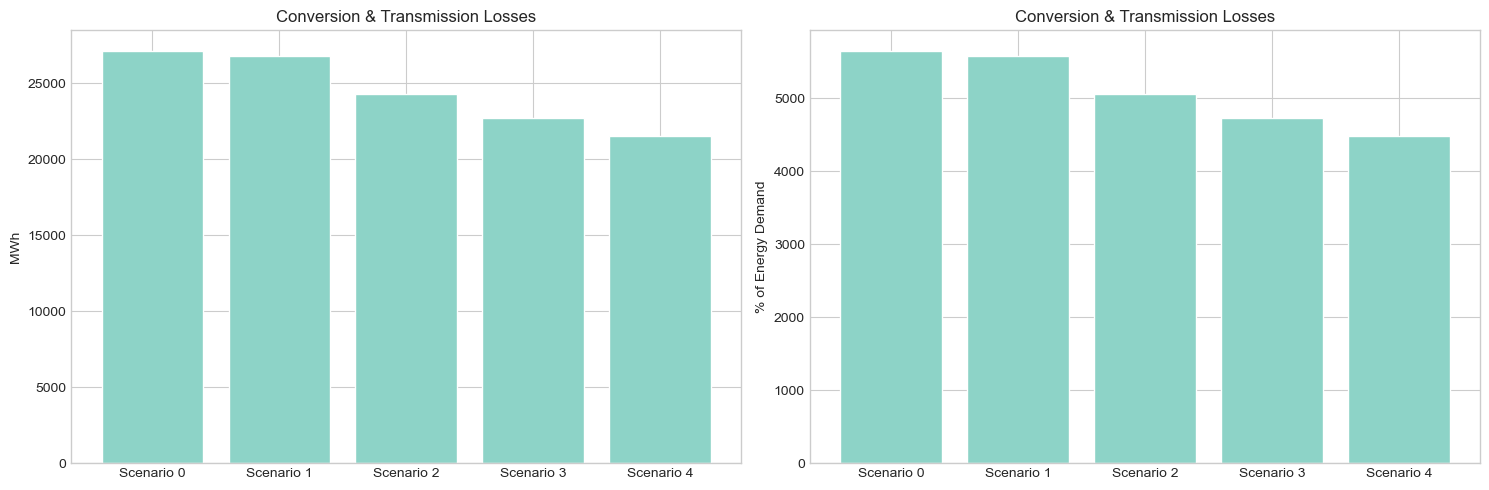

In [113]:
#transmission
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.flatten()

axes[0].bar(mm_scenarios, mm_conv_loss)
axes[0].set_title('Conversion & Transmission Losses')
axes[0].set_ylabel('MWh')
axes[1].bar(mm_scenarios, mm_conv_perc)
axes[1].set_title('Conversion & Transmission Losses')
axes[1].set_ylabel('% of Energy Demand')

plt.tight_layout(); plt.show()

### Line Utilization & H2 Tank Capacity

As shown in the figures below, the H2 tank size does not influence its time at either max or 0 capacity (see scenarios 1, 2 & 3). It sits at 8 hours when sized at all, and at full hours when not built (as can be expected). We suspect the hydrogen demand is generally too low, and it fluctuates too much to meaningfully impact this number without going beyond the given design constraint of 100 MWh.

Considering L12 line utilization, it becomes apparent that the introduction of battery and solar capacity while lowering wind capacity leads to slightly higher peaks in an otherwise seemingly consistent electricity profile. It is preferential to have as much wind capacity, to limit congestion, based on our scenarios.

L32 never reaches max capacity. This is because we never changed its value, as we saw that hydrogen was leading anyway and little to no difference in our decision would be made based on this KPIs result.

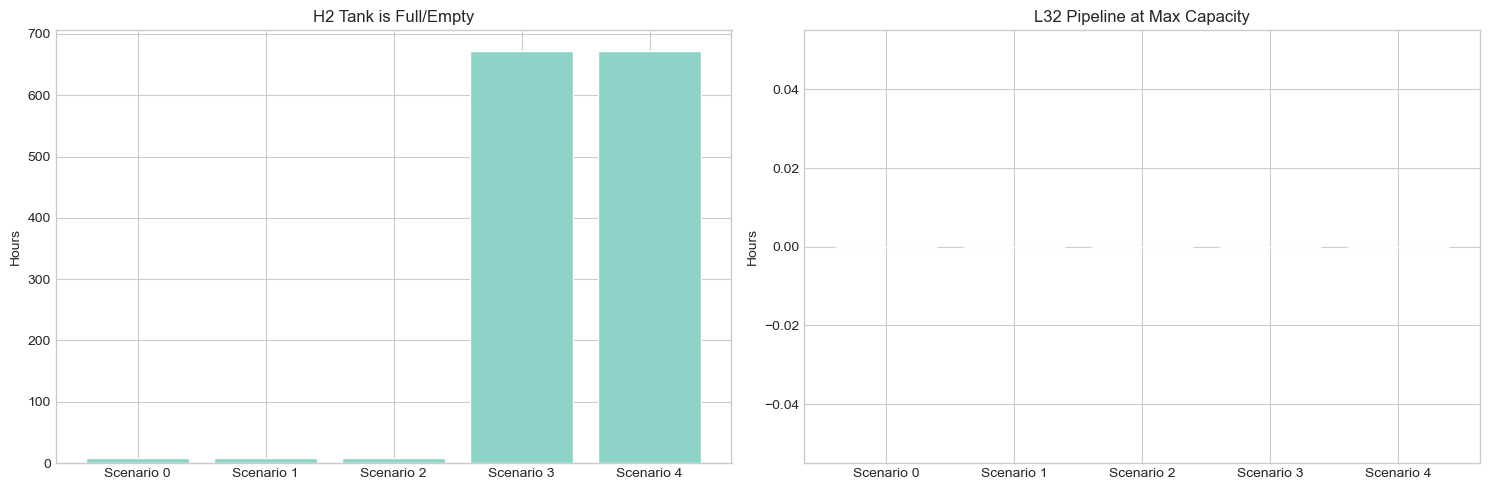

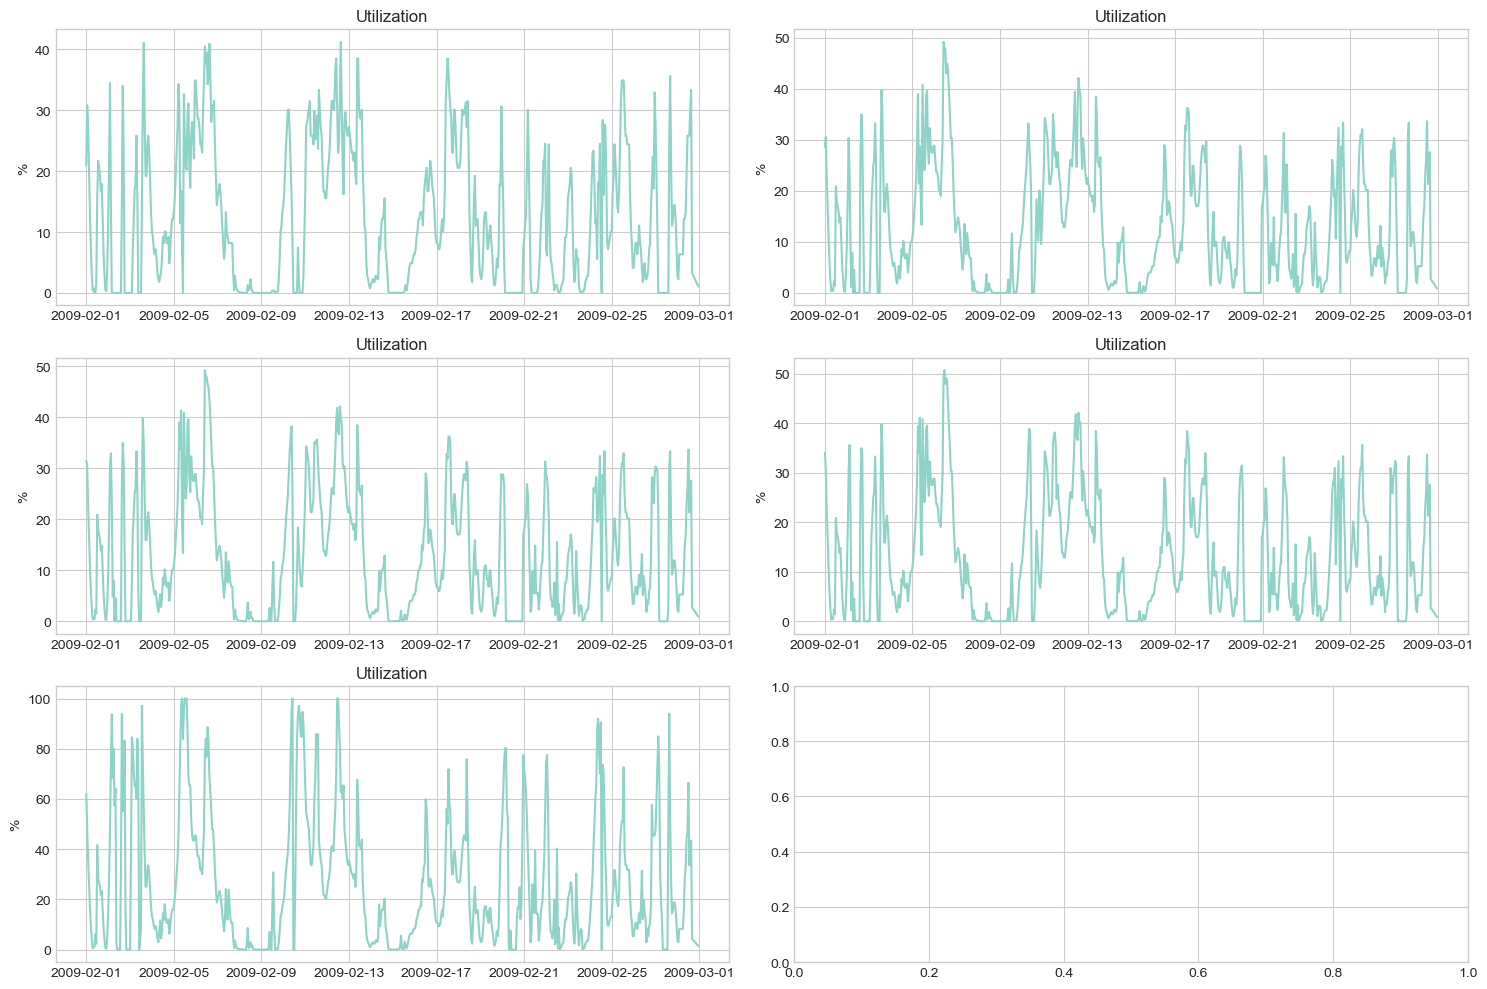

In [114]:
#capacity
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes = axes.flatten()

axes[0].bar(mm_scenarios, mm_count_h2)
axes[0].set_title('H2 Tank is Full/Empty')
axes[0].set_ylabel('Hours')
axes[1].bar(mm_scenarios, mm_count_L32)
axes[1].set_title('L32 Pipeline at Max Capacity')
axes[1].set_ylabel('Hours')

plt.tight_layout(); plt.show()

#utilization
fig, util = plt.subplots(3, 2, figsize=(15,10))
util = util.flatten()

util[0].plot(mm_util_sc0)
util[0].set_title('Utilization')
util[0].set_ylabel('%')
util[1].plot(mm_util_sc1)
util[1].set_title('Utilization')
util[1].set_ylabel('%')
util[2].plot(mm_util_sc2)
util[2].set_title('Utilization')
util[2].set_ylabel('%')
util[3].plot(mm_util_sc3)
util[3].set_title('Utilization')
util[3].set_ylabel('%')
util[4].plot(mm_util_sc4)
util[4].set_title('Utilization')
util[4].set_ylabel('%')
#these variables have to be stored in RAM, so run the model for all different models to get them. Shoddy solution due to a time constraints :(

plt.tight_layout(); plt.show()

### Unserved Demand

As the figures below show, heat demand was always met. This is mainly because the custom model calculates heat demand before electricity or hydrogen demand. We deemed this fitting as heating is quite important in winter months, so providing a non-zero supply is paramount. Moreover, considering penalties, it is beneficial to acquire LT heat from electricity as it multiplies the kWh by 3.5 and the HT heat was calculated first to avoid "double counting" the H2 penalty fee for lost HT heat.

Electricity demand was still unmet at times, which can be explained by the intermittency of our RES generation. Building a (larger) battery limits this (as can be seen by the jump from scenario 0 to 1) but without proper transmission lines and high enough peak RES generation this will not impact the unserved electricity demand much. It is a trade off.

Hydrogen demand is at a constant unmet demand, as our generation is limited to the available H2. As the figures below the model section shows, this unserved demand is not a constant over time, as at other points in time the H2 generated is higher than demand and storage can take up. However, over the complete time series this disparity becomes apparent.

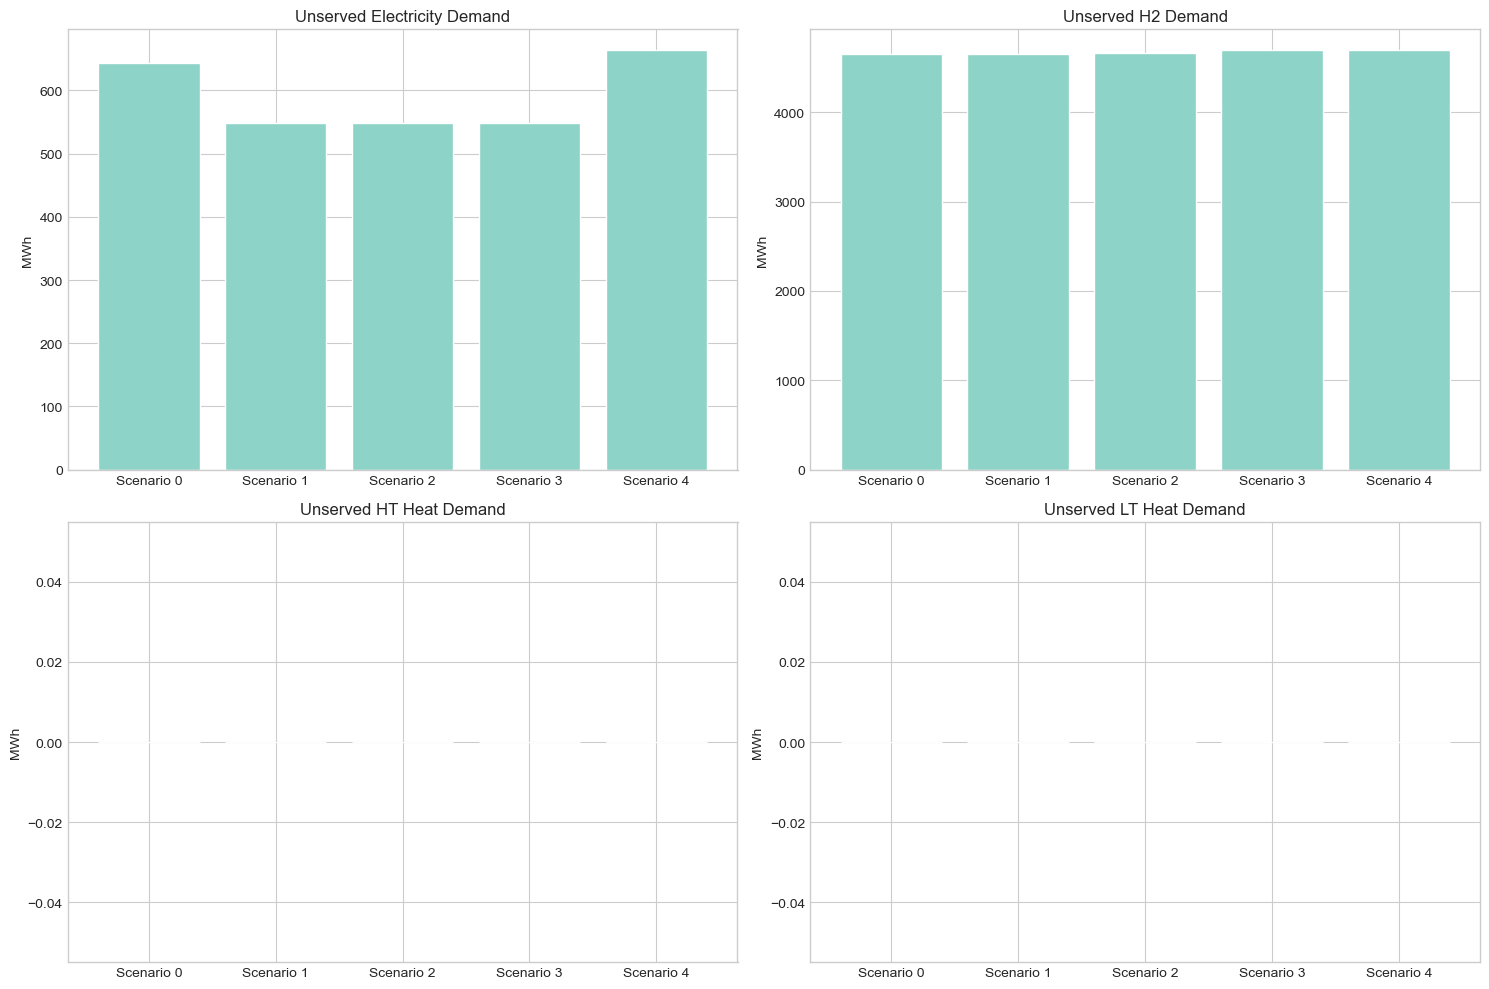

In [115]:
#unserved
fig, uns = plt.subplots(2, 2, figsize=(15, 10))
uns = uns.flatten()

uns[0].bar(mm_scenarios, mm_el_unserved)
uns[0].set_title('Unserved Electricity Demand')
uns[0].set_ylabel('MWh')
uns[1].bar(mm_scenarios, mm_h2_unserved)
uns[1].set_title('Unserved H2 Demand')
uns[1].set_ylabel('MWh')
uns[2].bar(mm_scenarios, mm_ht_unserved)
uns[2].set_title('Unserved HT Heat Demand')
uns[2].set_ylabel('MWh')
uns[3].bar(mm_scenarios, mm_lt_unserved)
uns[3].set_title('Unserved LT Heat Demand')
uns[3].set_ylabel('MWh')

plt.tight_layout(); plt.show()

### Project Uncertainty

Our last KPI is project uncertainty, and for which we introduced the possibility of additional construction in Part 2 to be neglected, unsuitable or altogether forgotten. This KPI was meant to simulate how this project can be left incomplete and how that affects the other KPIs. As can be seen from the system costs, scenario 4 has not much higher costs than scenarios 2 & 3, and lower costs than scenarios 0 & 1. Therefore, we deem this KPI reasonable from a purely financially interested party.

We see that unserved demand increases or stays constant compared to other scenarios, and import increases. As a call-back to our Part 1 discussion, this would also decrease our region's energy security. Our line L12 utilization likewise sees moments where it goes beyond 100% and as a result would indicate outages. Still, other variables see little or desirable changes (such as conversion losses and curtailment), making us believe this scenario is not unlikely.

### Final Reflections for Part 2

This assignment has shown how certain variables work together in simulating an energy system, and how they relate to one another. Our scenarios were dominated by the hydrogen sector which led to our own introduction of project uncertainty under extremely limiting conditions. Still, our scenarios gave some insights in more worthwhile trajectories than others in such a dominated landscape.

We saw that curtailment and conversion losses decrease when limiting the capacity of 1 RES generator (in our case wind), and instead install solar and battery capacity. This also lowered overall system costs, and though not an explicit KPI in part 2 increases domestic production safety and energy security as a result. However, it also increases electricity import to meet demand, as for our time and location solar is not as robust as wind.

Unserved demand remained constant for all scenarios (apart from electricity), which again indicates that the installation of heat and hydrogen storage does very little in our case to ensure demand is met at all times. Line utilization and the H2 tank capacity also highlight how demanding this sector is in our case. It seems most likely that our time and location combine into a quite difficult picture to ensure hydrogen and electricity generation meets demand. This again leads back to intermittency.

Based on all our findings, we would choose scenario 2 as our final energy system to weigh all pros and cons against one another.

That leads into our design limitations. This model is custom-made and will probably have oversights in its design as well as assumptions that limit its overall effectiveness. For example, the model works linearly. It first considers heat demand before considering electricity and hydrogen demand, leading to heat being valued over the other two. Redesigning the model to account for a trade-off between these demands would entail setting another value as leading. Now the leading value is heat's intrinsic value during winter times, but it could be minimizing system costs, which would lead to the introduction of new variables to track overall costs. Likely then, HT heat would often become unserved because of conversion losses.

Another limitation is the absence of a prediction horizon. Implementing this would require implementing a larger view window for all storage unit 'if' statements. This would allow the 'if' statement to consider more that just the current step, and store more or less energy depending on its forecast. Our reasons for not doing so in this model are outlined in Part 1, but boil down to the unpredictability of energy availability. As in Part 2 we also saw project uncertainty as a KPI, we elected to keep the time horizon extremely limited.

### Design Limitations

In order to account for more than 1 month of weather data we would first need data on other months' weather. This data is supplied, so we would run our current scenario (2) using the other input data as we did for our month. The data would preferably be of the same year, with other years given less "weight" to account for potential disparities.

Next we would compare the outcomes of all different input weather data to notice any outliers in the KPIs that we have given here. This data would have to be stored in a separate file to call on for later use for figures. This would look similar to how we ran scenarios for the current model. Then, based on the differences in weather (namely wind and solar capacity factors, and energy demand) we would heuristically alter our model to account for these differences.

If we wanted to model an energy system specific to February, we would for then perhaps increase storage and their stored amounts (as perhaps energy was stored before the month commenced). If we wanted to model an energy system for 1 year, we would instead try to level all input parameters to maintain an average computability of the system for all times and weather conditions of the year.

In order to improve our energy system model when one component is temporarily unavailable, we would first need data on how often and long such instances last. The assignment says to take 3 days in Part 3, so we would use that estimate.

Next we would simulate multiple runs where either L21, L32, any storages or generation sites becomes unavailable. It can be any object, but in order to say something meaningful we believe it is best to investigate on object at a time. We assume this unavailability to be a random chance, so this will be accounted for in the for loop as happening randomly at any time during the month. We must make sure it happens once (and no more thereafter for computational purposes). This would then produce a period of 3 days when that object's capacity is zero. Preferably this simulation is run multiple times in order to obtain an average variability in KPIs.

Then we would introduce different parameters for different scenarios and compare the KPIs of all to eventually end up with the most robust energy system for a potential unavailability.

### Statement of Collaboration
Both of us worked on the assignment with equal effort. We often spent our time working together and discussed much in person. Kevin was mainly concerned with the PyPSA model and provided most insights in Part 1, while Stef was mainly concerned with the custom model and provided most insights in Part 2. The pitch was prepared by us both. Part 3 was done by Kevin while Stef collected all files and prepared everything for submission.

### AI Disclosure Statement
Is included in a separate PDF file.